In [ ]:
import sisl
from Zandpack.TimedependentTransport import TD_Transport
import numpy as np
import matplotlib.pyplot as plt
from Zandpack.FittingTools import find_correction
from ase.build import molecule

## Nanotube with H2O on the side
In this tutorial we use tight-binding to describe a carbon-nanotube while we simultaneously couple a water molecule onto the nanotube. The H2O molecules Hamiltonian has been calculated with a siesta calculation with a large cell. It gives an idea of the flexibility of the sisl objects and how to exploit this.

True


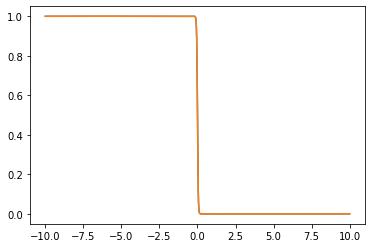

Directory called EM already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
Directory called EP already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
Directory called Device already exists! Remove it? (y/reuse/n)
No atoms overlapping within 0.3 Å!
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], [128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159]]
Running TB-Trans in Directory: Device!

Normal plot

 Building ES - H - Self Energies 

[0]

 Overlap Included!

Normal plot


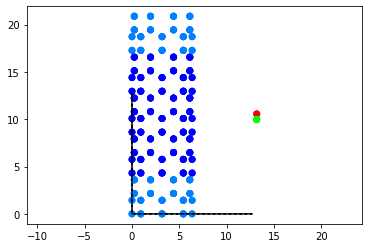

/home/aleksander/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


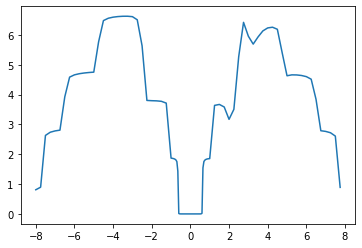

In [14]:
_H_h2o = sisl.get_sile('siesta.TSHS').read_hamiltonian()
H_h2o  = _H_h2o.Hk()
g_h2o  = sisl.get_sile('siesta.TSHS').read_geometry()

a  = 1.44
tz = 5

C      =   sisl.Atom('C', R= 1.6)
_cnt   =   sisl.geom.nanotube(a,atoms = C, chirality = (8,0))
C      =  _cnt.tile(tz,2).center()
g_h2o  =   g_h2o.move(C).move([10,0,0])
_cnt2  =  _cnt.tile(tz,2)
cnt    =  _cnt2.add(g_h2o)


def func(self, ia, atoms, atoms_xyz=None):
    is_cnt = (np.linalg.norm(self.geometry.xyz[ia] - _cnt2.xyz,axis=1)<0.1).any()
    if is_cnt:
        idx = self.geometry.close(ia, R=[0.1, 1.44*1.1], atoms=atoms, atoms_xyz=atoms_xyz)
        self[ia, idx[0]] = 0
        self[ia, idx[1]] = -2.7
    else:
        pass

dev = sisl.Hamiltonian(cnt)
dev.set_nsc((1,1,1))
em  = sisl.Hamiltonian(_cnt.copy())
ep  = sisl.Hamiltonian(_cnt.copy().move(dev.cell[2,:] - em.cell[2,:]))
dev.construct(func)
em.construct( [[0.1, a * 1.1],[0.0, -2.7]])
ep.construct( [[0.1, a * 1.1],[0.0, -2.7]])

Hd = dev.Hk().toarray()
print(np.allclose(Hd, Hd.T.conj()))
offset = _cnt2.na
for io in range(H_h2o.shape[0]):
    for jo in range(H_h2o.shape[0]):
        dev[offset + io, offset+jo] = H_h2o[io,jo]
            
diff = np.linalg.norm(_cnt2.xyz - C, axis=1)
idx  = np.where(diff == diff.min())[0][0]
dev[offset+1,idx]  = 3.0
dev[idx, offset+1] = 3.0


eta  = 1j  * 1e-2
#line = np.linspace(-8, 8, 250) + eta  + 1e-5
line = np.hstack((np.arange(-8,-1,0.25), np.arange(-1,1, 0.05),np.arange(1,8, 0.25)))
#print(line.shape)

line = np.vstack((line,line))+eta+1e-4

    
    
D = TD_Transport([em.geometry,ep.geometry], dev, kT_i = [0.025, 0.025])
D.Make_Contour(line, 20, pole_mode = 'JieHu2011')
plt.show()

D.Electrodes( semi_infs = ['-a3', '+a3'] , kp = [[1,1,50], [1,1,50]])
D.make_device()
D.run_electrodes(fois_gras_H = [em,ep])
dev_rear = dev.sub(D.Device._rearange_indices)
D.run_device(    fois_gras_H = dev_rear)
xyz_N = np.array([dev_rear.xyz[dev_rear.o2a(i)] for i in range(dev_rear.no)])
np.save('Pos_Prepivot.npy',xyz_N, )

D.Device.Visualise(axes=[0,2])
D.read_data()
D.Device.Visualise(axes = [0,2])
plt.show()
plt.plot(line[0],D.tbtT[D.sampling_idx[0]])

In [20]:
#D.reset_all_fits() # Comment in to reset fits!
# In[]
Eg = np.linspace(-8,8,300)
#Test.reset_all_fits()
Emin,Emax = -7,7

NL = 41
E  = np.linspace(Emin, Emax,NL)

E[0:NL//2] -= .5
E[NL//2+1:]+= .5


E1 = E.copy()
E2 = E.copy()


init_E = [E1[None,:],E2[None,:]]
number = 0.2*(41/NL)**0.5
G = np.ones(init_E[0].shape)*number
G[0,(NL//2-3):(NL//2+4)] = number/2
G[0,NL//2] = number/30


G1 = G.copy()
G2 = G.copy()


init_G = [G1,G2]
alpha_PO = 0.001

min_tol = np.zeros((1,NL))

def run_mini(its,method, elecs = None):
    D.Fit(fact = 0.6,                            # Redundant when we give init_E and init_G
          Fallback_W = 5.0,                    # Redundant\n",
          NumL = NL,                           # Not redundant\n",
          fit_mode = 'all',                    # Important to choose mode\n",
          force_PSD     = True,                # the self-energies are not positive semidefinite
          force_PSD_tol = [min_tol,
                           min_tol], # 
          use_analytical_jac = False,          # Important for speed
          min_method = method,                 # Choose from any scipy.optimize.minimize method
          ebounds = (-7.5,7.5),                # bounds on centres
          wbounds = (0.0001, 3),               # bounds on widths
          gbounds = (None, None),              # bounds on sizes, redundant right now
          tol = 1e-5,                          # any negative value with mean we fit all matrix elements of \\Gamma
          options = {'disp':True,              # Minimizer options
                     'maxiter':its, 
                     'gtol':1e-10, 
                     #'iprint':1,
                     },
          
          fit_real_part = False,               # 
          alpha_PO      = alpha_PO,            # Repulsion
          init_E        = init_E,              # Give initial ei's and gi's
          init_G        = init_G,
          which_e       = elecs
          )
    C = find_correction(D)
    D.Renormalise_H(C)
print(E1)

[-7.5  -7.15 -6.8  -6.45 -6.1  -5.75 -5.4  -5.05 -4.7  -4.35 -4.   -3.65
 -3.3  -2.95 -2.6  -2.25 -1.9  -1.55 -1.2  -0.85  0.    0.85  1.2   1.55
  1.9   2.25  2.6   2.95  3.3   3.65  4.    4.35  4.7   5.05  5.4   5.75
  6.1   6.45  6.8   7.15  7.5 ]


In [21]:
#D.reset_all_fits()
run_mini(0,'nelder-mead')
print('Blocks of first electrode')
print(D.fitted_lorentzians[0].is_zero)
print('Blocks of second electrode')
print(D.fitted_lorentzians[1].is_zero)

# We access the blocks of the fitted matrices like this:
# only block (0,0) is nonzero
for iL in [17,18,19,21,22,23]:
    for i,v in enumerate(D.fitted_lorentzians[0].vals):
        v[:,iL]*=0.5
        print(D.fitted_lorentzians[0].inds[i])
    for v in D.fitted_lorentzians[1].vals:
        v[:,iL]*=0.5
        print(D.fitted_lorentzians[1].inds[i])


Finding Lambda matrices:

Rerun


--------------------
Optimizing Lorentzian Expansion
--------------------

8
Lorentzian fit took 3.1755080223083496 seconds.
Finding Lambda matrices:

Rerun


--------------------
Optimizing Lorentzian Expansion
--------------------

8
Lorentzian fit took 2.737704277038574 seconds.
Blocks of first electrode
[[1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]
Blocks of second electrode
[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 

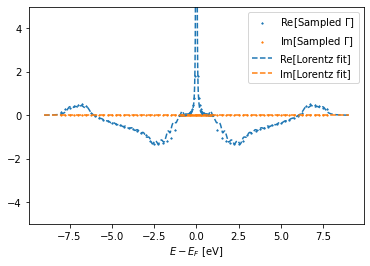

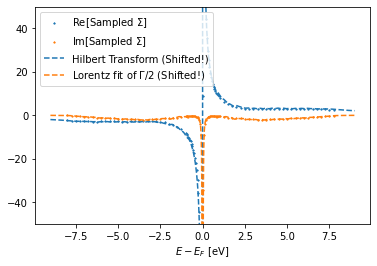

In [22]:
IK = 0
D.Inspect_Lorentzian_fit(0,0,0,0,2, ik = IK, Emin = -9, Emax = 9, center_lines = False, n_samples=1000)
plt.xlabel(r'$E-E_F$ [eV]')
plt.ylim([-5,5])
#plt.xlim([-1,1])
plt.show()
D.Inspect_SE_from_hilbert_transform(0,0,0,2,2, ik = IK, Emin = -9, Emax = 9, n_samples=1000)
plt.xlabel(r'$E-E_F$ [eV]')
plt.ylim([-50,50])
#plt.xlim([-1,1])
plt.show()

#D.Inspect_Lorentzian_fit(1,11,11,1,0,                          ik = IK, Emin = -7, Emax = 7)
#plt.show()
#D.Inspect_Lorentzian_fit(0,0,0,1,1,                            ik = IK, Emin = -7, Emax = 7)
#plt.show()
#D.Inspect_Lorentzian_fit(0,0,0,1,0,                            ik = IK, Emin = -7, Emax = 7)


Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 6428.385086
Minimum of eigenvalues of Lorentzian Gammas: -0.0
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)


/home/aleksander/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(-5.0, 5.0)

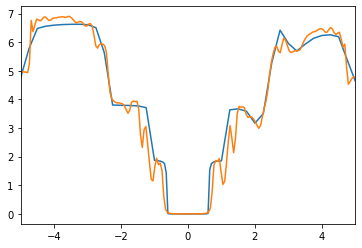

In [23]:
D.tofile('NR')
D.Inspect_transmission_from_hilbert_transform(E=Eg,eta=1e-3, NO=False)
plt.xlim([-5,5])
#D.Check_input_to_ODE()

In [24]:
D.tofile('NT')

Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 6428.385086
Minimum of eigenvalues of Lorentzian Gammas: -0.0
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)


In [31]:
!SCF Dir=$PWD file=NT
!psinought Dir=$PWD file=NT add_random=True random_weight=0.00001 steptol=1e-5


SCF Program Start

sys.argv: ['/home/aleksander/Desktop/Input_hpc_master/PythonModules/Zandpack/Zandpack/cmdtools/SCF', 'Dir=/home/aleksander/Desktop/nb_tutorial/TightBinding/T7.1:Nanotube+HF', 'file=NT']

----> Mu =  [0. 0.]
----> Bias=  [ 0. -0.]
Contour-file:   /home/aleksander/Desktop/Input_hpc_master/PythonModules/Zandpack/Zandpack/cmdtools/SCF_default_Contour.npy
2
Evaluating SEs
Done
Iteration  1 | dN_max:   0.000991 | Qtot_k [50.968618+0.j]
Iteration  2 | dN_max:   0.000297 | Qtot_k [50.954066+0.j]
Iteration  3 | dN_max:   0.0 | Qtot_k [50.954066+0.j]
psinought Program Start

sys.argv: ['/home/aleksander/Desktop/Input_hpc_master/PythonModules/Zandpack/Zandpack/cmdtools/psinought', 'Dir=/home/aleksander/Desktop/nb_tutorial/TightBinding/T7.1:Nanotube+HF', 'file=NT', 'add_random=True', 'random_weight=0.00001', 'steptol=1e-5']

psinought: Reading arrays.....
DM input from  NT/Arrays/DM_Ortho.npy
psinought: Converging steady-state with DM from     NT/Arrays/   folder.
psinought: Par

In [32]:
!mpirun -np 3 SuperZand Dir=$PWD

[1, 2]

  
  Zand
  
  Program developed for time-dependent transport in nanostructures 
  at DTU.
  
  Author: Aleksander Bach Lorentzen, DTU ( abalo@dtu.dk / aleksander.bl.mail@gmail.com )
  Supervisor: Mads Brandbyge, DTU.
    - Nick Papior from DTU compute has constributed with performance tips.
    - Alexander Croy from Friedrich Schiller University has contributed 
      with methods for consistency checks and steadystate solution. 


  Please cite this article:
       ***Cool Article Bibtex***  

  
  Basic function of this program:
  There are two scripts that needs to accompany this program:
 
  The "Initial.py" script, which has the information of the 
  initial and final times, error tolerance, and how often the script 
  should save the device state and some other periferal things.

  The "Bias.py" should contain a function called bias that returns a 
  number and has arguments bias = bias(t,a), where t is time and a 
  is the lead index.
  It should also contain a function

t=-84.214 | #steps=350 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-82.004 | #steps=400 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-79.794 | #steps=450 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-77.583 | #steps=500 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-75.373 | #steps=550 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-73.163 | #steps=600 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-70.953 | #steps=650 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-68.742 | #steps=700 | eps=5.905e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=-66.532 | #steps=750 | eps=5.905e-06
 

t=59.076 | #steps=3600 | eps=5.905e-06
    Bias_0: 1.999766   | J_0: 0.55643| Total: 0.55643
    Bias_1: -1.999766   | J_1: -0.553776| Total: -0.553776
t=61.198 | #steps=3650 | eps=5.905e-06
    Bias_0: 1.999972   | J_0: 0.565264| Total: 0.565264
    Bias_1: -1.999972   | J_1: -0.563014| Total: -0.563014
t=63.319 | #steps=3700 | eps=5.905e-06
    Bias_0: 1.999997   | J_0: 0.563645| Total: 0.563645
    Bias_1: -1.999997   | J_1: -0.562288| Total: -0.562288
t=65.441 | #steps=3750 | eps=5.905e-06
    Bias_0: 1.999999   | J_0: 0.561711| Total: 0.561711
    Bias_1: -1.999999   | J_1: -0.560814| Total: -0.560814
t=67.563 | #steps=3800 | eps=5.905e-06
    Bias_0: 1.999992   | J_0: 0.561605| Total: 0.561605
    Bias_1: -1.999992   | J_1: -0.561131| Total: -0.561131
t=69.684 | #steps=3850 | eps=5.905e-06
    Bias_0: 1.999935   | J_0: 0.561073| Total: 0.561073
    Bias_1: -1.999935   | J_1: -0.560928| Total: -0.560928
t=71.806 | #steps=3900 | eps=5.905e-06
    Bias_0: 1.999459   | J_0: 0.560622|

t=150.347 | #steps=6550 | eps=5.908e-06
    Bias_0: 0.0   | J_0: -0.| Total: -0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=151.447 | #steps=6600 | eps=5.907e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: -0.| Total: -0.0
t=152.543 | #steps=6650 | eps=5.907e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: -0.| Total: -0.0
t=153.634 | #steps=6700 | eps=5.907e-06
    Bias_0: 0.0   | J_0: -0.| Total: -0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=154.721 | #steps=6750 | eps=5.907e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: -0.| Total: -0.0
t=155.803 | #steps=6800 | eps=5.907e-06
    Bias_0: 0.0   | J_0: 0.| Total: 0.0
    Bias_1: -0.0   | J_1: -0.| Total: -0.0
t=156.881 | #steps=6850 | eps=5.907e-06
    Bias_0: 0.0   | J_0: -0.| Total: -0.0
    Bias_1: -0.0   | J_1: 0.| Total: 0.0
t=157.955 | #steps=6900 | eps=5.907e-06
    Bias_0: 0.0   | J_0: -0.| Total: -0.0
    Bias_1: -0.0   | J_1: -0.| Total: -0.0
t=159.025 | #s